Mounted at /content/drive
Current directory: /content/drive/MyDrive/MBP_PREDICTOR
Starting feature visualization and analysis...

LOADING EXTRACTED FEATURES
Checking data directory contents...
Available CSV files in data/: ['mbp_dataset.csv', 'mbp_dataset_cleaned.csv', 'features_cleaned_with_embeddings.csv']
Found features_cleaned_with_embeddings.csv - loading...
Features loaded successfully!
Feature dataset shape: (3072, 1057)
Columns: 1057 total

Feature breakdown:
  Embedding features: 1024
  AAC features: 20
  Motif features: 6
  Physicochemical features: 5
  Traditional features total: 31

Class distribution:
Label
0    1539
1    1533
Name: count, dtype: int64
Balance ratio: 0.996

TRADITIONAL FEATURE ANALYSIS
Statistical comparison (MBP vs Non-MBP):
--------------------------------------------------------------------------------
Feature         MBP Mean   Non-MBP Mean P-value    Significant
--------------------------------------------------------------------------------
AAC_K    

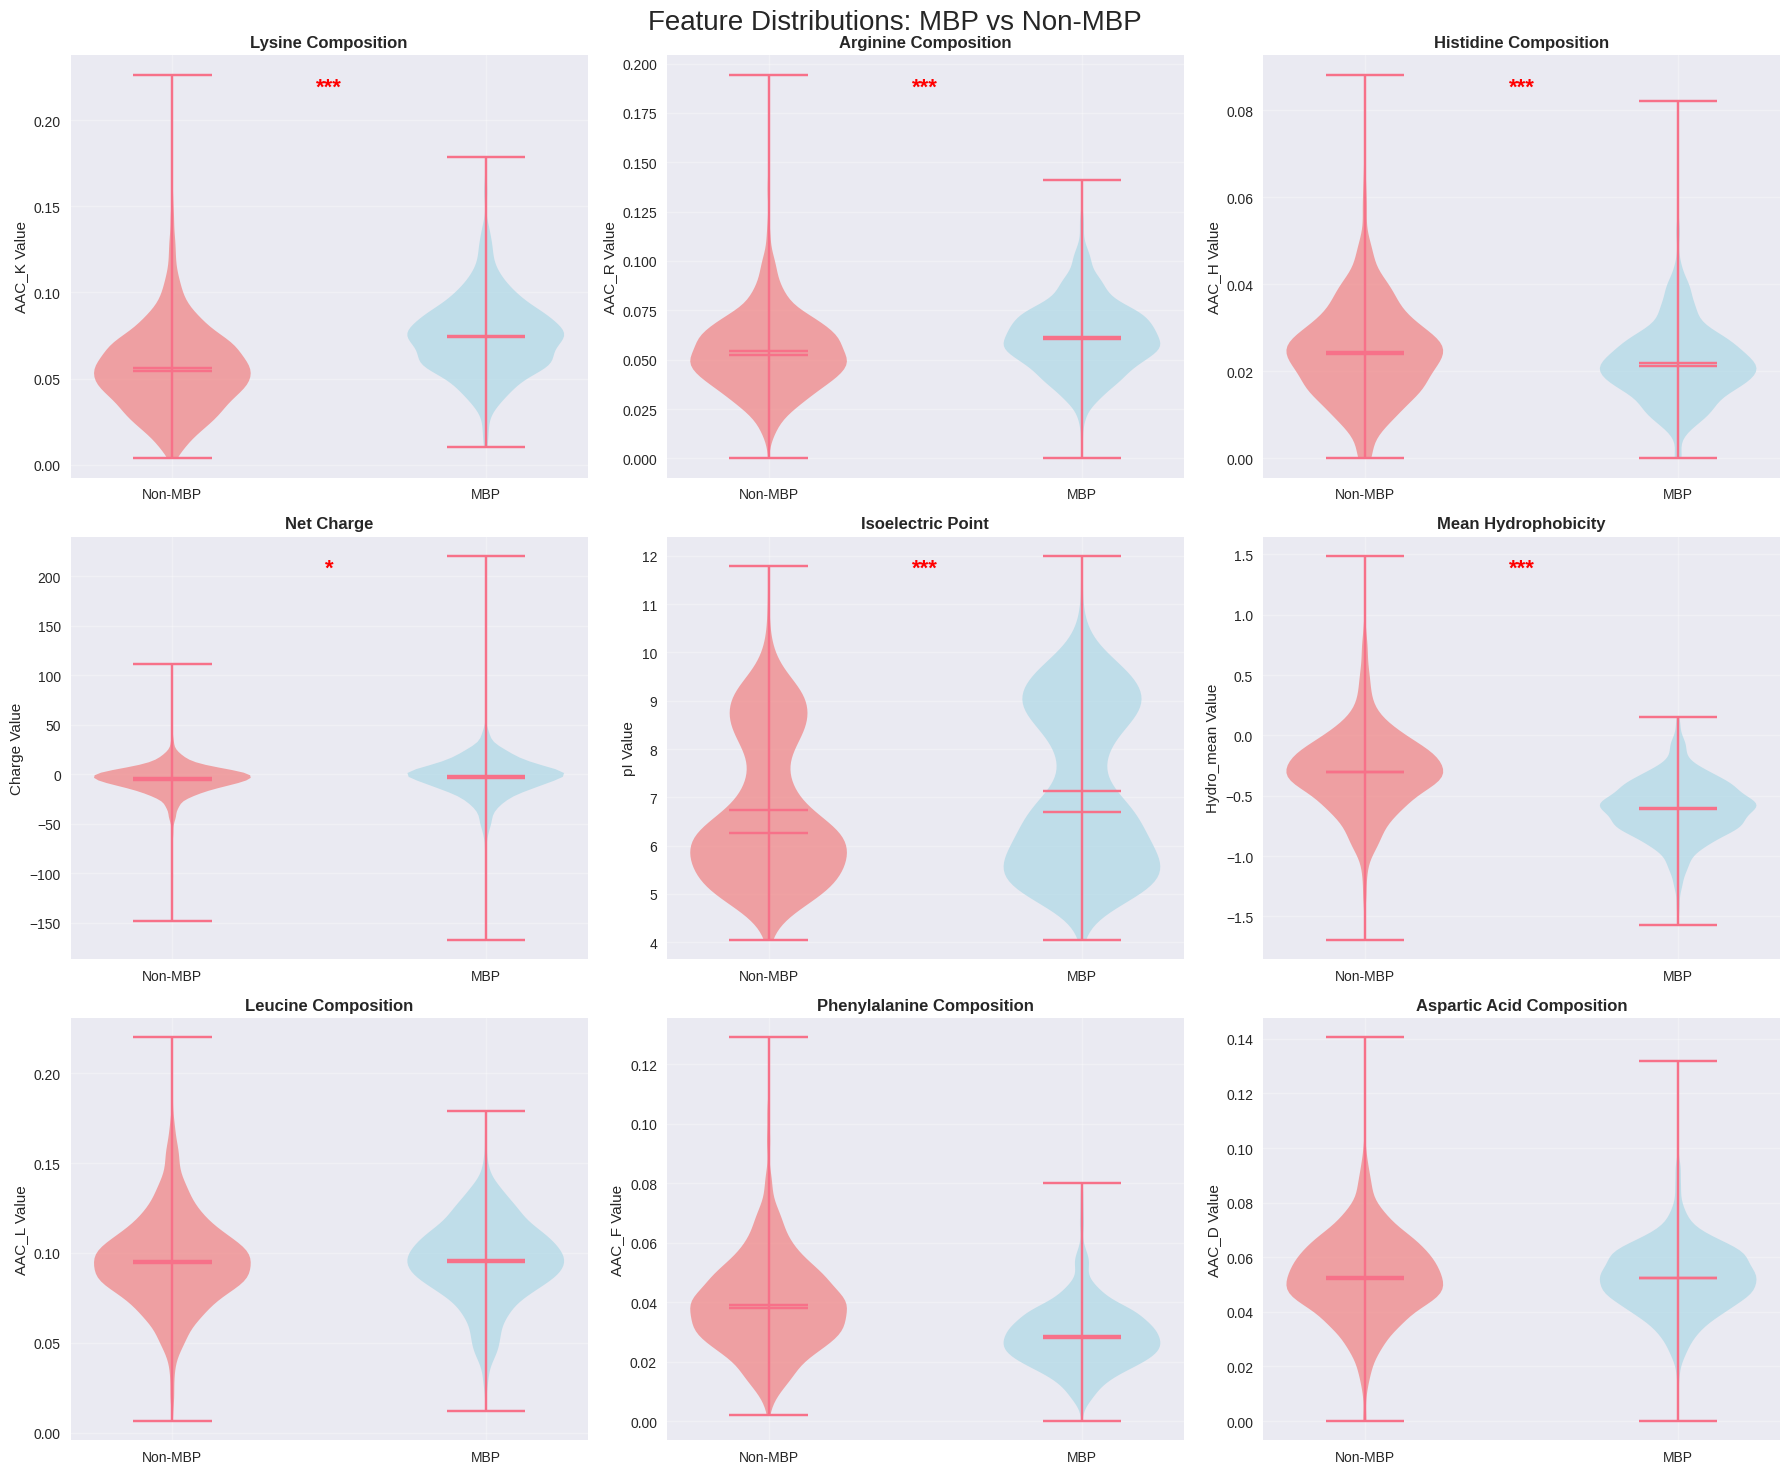


MOTIF PREVALENCE ANALYSIS


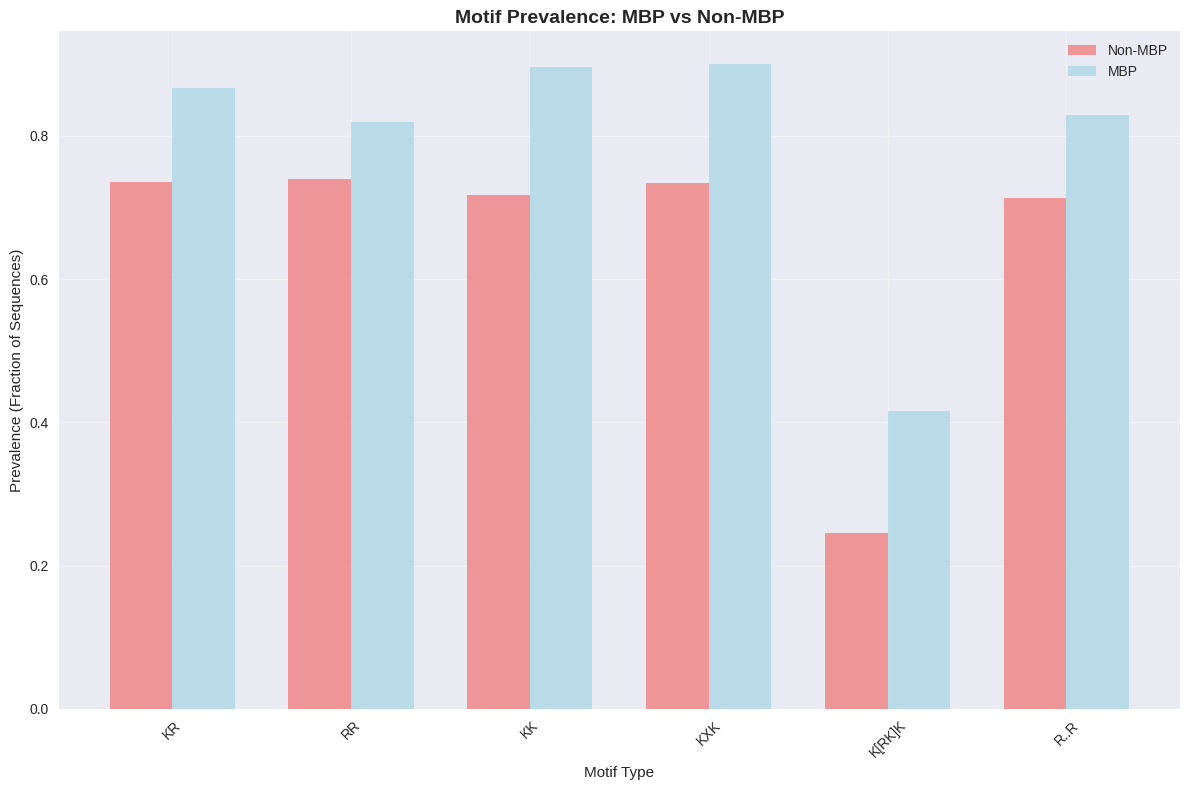

Motif prevalence comparison:
       Motif_KR  Motif_RR  Motif_KK  Motif_KXK  Motif_K[RK]K  Motif_R..R
Label                                                                   
0         0.735     0.740     0.717      0.734         0.246       0.713
1         0.867     0.819     0.896      0.901         0.416       0.828

HIGH-DIMENSIONAL EMBEDDING VISUALIZATION
Analyzing 1024 embedding dimensions...
Embedding matrix shape: (3072, 1024)

Performing PCA...
PCA explained variance ratio (first 10 components): [0.29083983 0.2392634  0.05800933 0.0399152  0.03168037 0.02028186
 0.01984019 0.01659179 0.01482694 0.01371655]
Cumulative variance explained by first 10 components: 0.745
Performing t-SNE...
Performing UMAP...


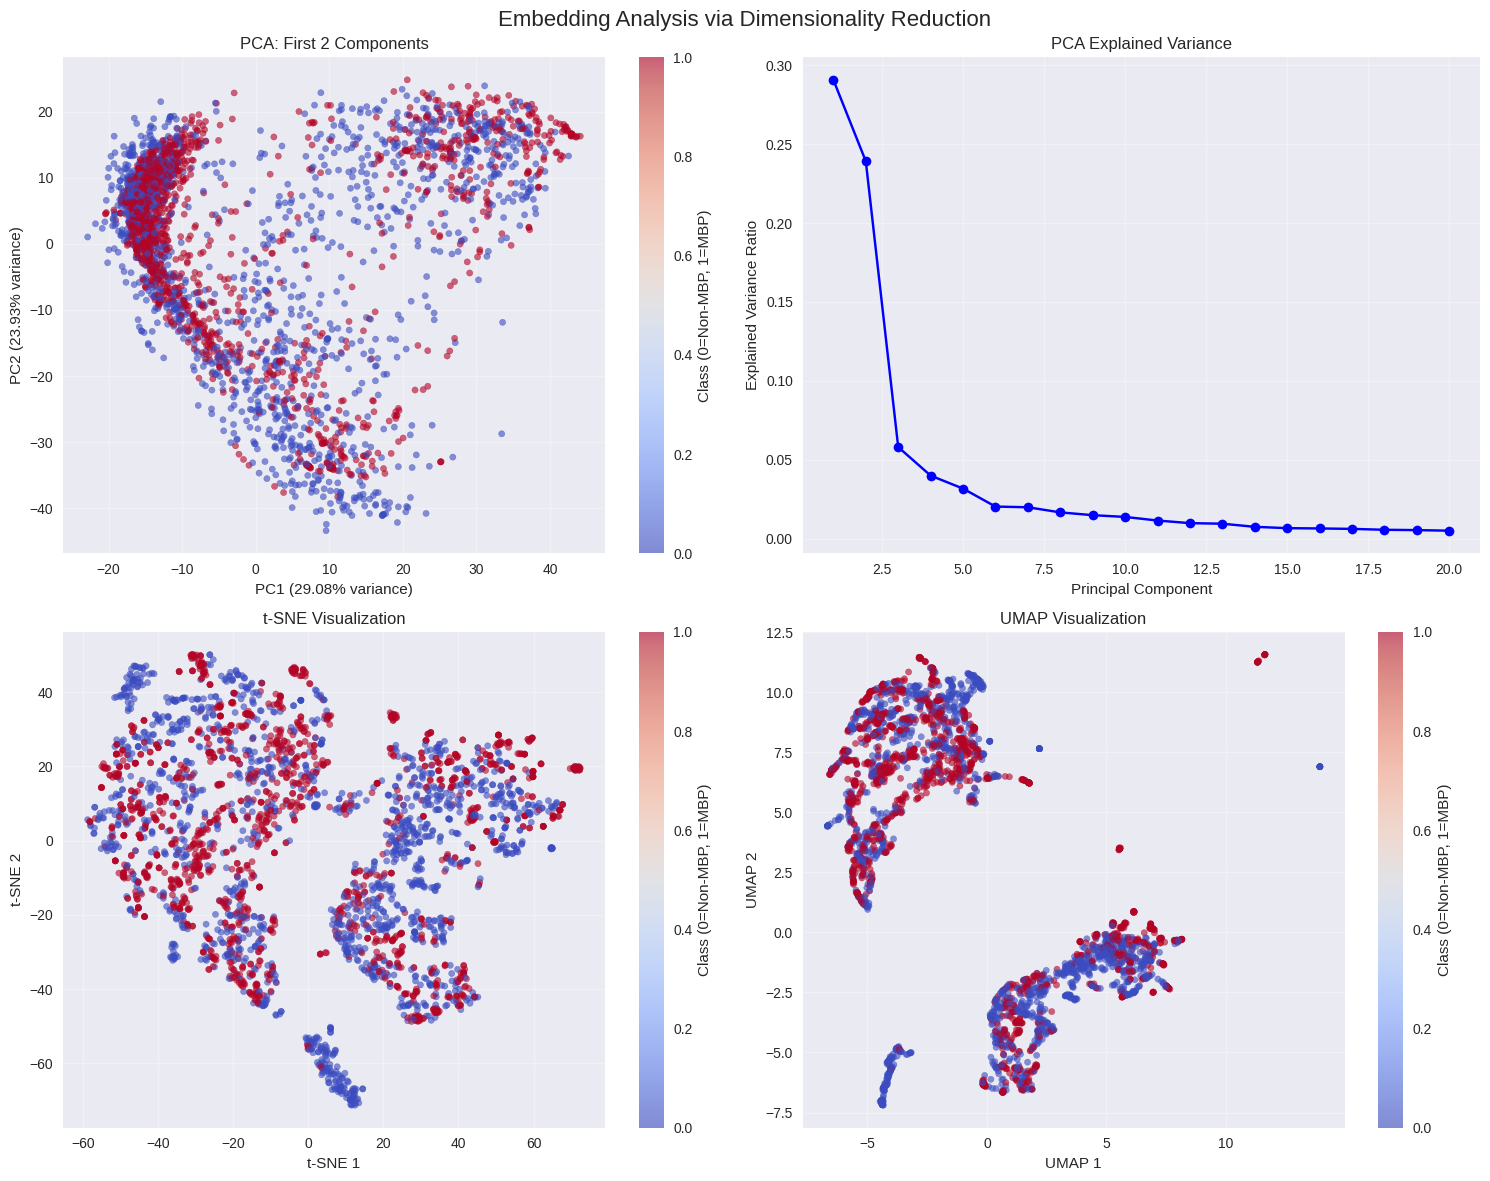


FEATURE CORRELATION ANALYSIS
Computing correlation matrix for 31 traditional features...

Highly correlated feature pairs (|correlation| > 0.7):
  Charge <-> pI: 0.747


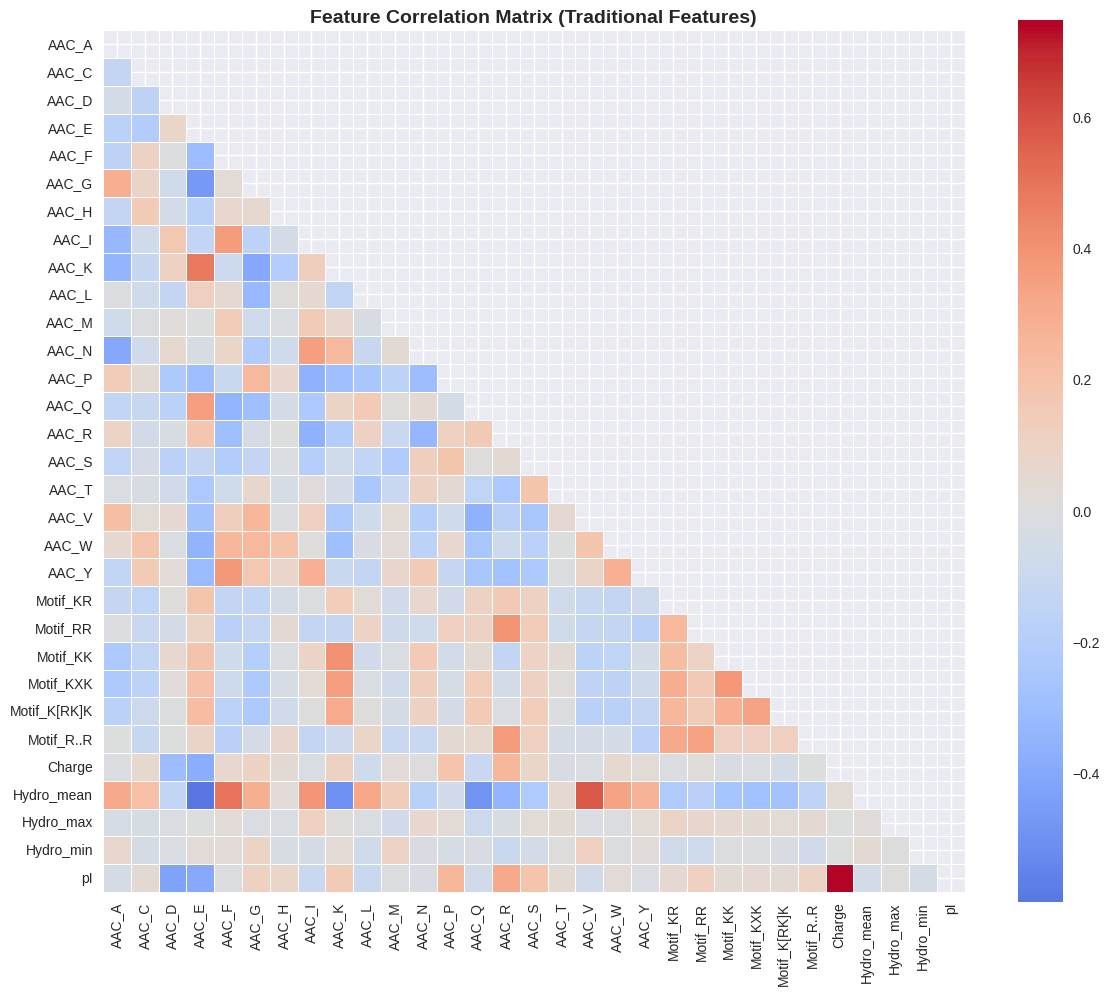

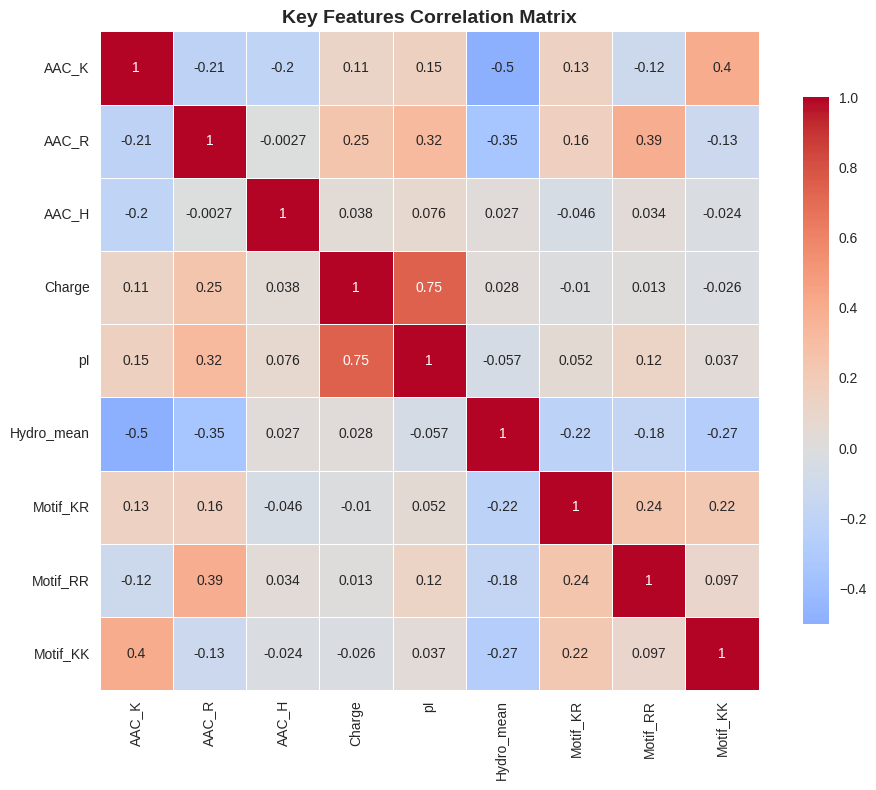


SUMMARY FOR PRESENTATION
KEY FINDINGS:
----------------------------------------
Most discriminative features (by t-statistic):
1. Hydro_mean: MBPs have lower values (p=0.0000)
2. AAC_K: MBPs have higher values (p=0.0000)
3. Motif_KK: MBPs have higher values (p=0.0000)
4. AAC_R: MBPs have higher values (p=0.0000)
5. Motif_KR: MBPs have higher values (p=0.0000)

Embedding analysis:
- Embedding dimensions: 1024
- PCA top 10 components explain 74.5% of variance
- Visual clustering observed in t-SNE and UMAP plots

Dataset summary:
- Total sequences: 3072
- MBP sequences: 1533 (49.9%)
- Non-MBP sequences: 1539 (50.1%)
- Total features extracted: 1055

RECOMMENDATIONS FOR PPT:
----------------------------------------
1. Show the violin plot for Lysine (AAC_K) or Net Charge - clear separation
2. Include t-SNE or UMAP plot showing MBP clustering
3. Show motif prevalence bar chart if motifs are discriminative
4. Mention top 3 most discriminative features from statistical analysis

Visualizatio

In [4]:
# Feature Visualization and Analysis Notebook
# Analyzing extracted features from MBP dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
from sklearn.preprocessing import StandardScaler
from scipy.stats import ttest_ind
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive and navigate to project directory
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/MBP_PREDICTOR')
print(f"Current directory: {os.getcwd()}")

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Starting feature visualization and analysis...")

# =============================================================================
# 1. LOAD EXTRACTED FEATURES
# =============================================================================

print("\n" + "="*60)
print("LOADING EXTRACTED FEATURES")
print("="*60)

# Check what feature files exist
print("Checking data directory contents...")
try:
    data_files = [f for f in os.listdir('data/') if f.endswith('.csv')]
    print(f"Available CSV files in data/: {data_files}")

    # Load the features file
    if 'features_cleaned_with_embeddings.csv' in data_files:
        print("Found features_cleaned_with_embeddings.csv - loading...")
        df_features = pd.read_csv('data/features_cleaned_with_embeddings.csv')
        print("Features loaded successfully!")
    else:
        print("ERROR: features_cleaned_with_embeddings.csv not found!")
        print("Available files:", data_files)
        raise FileNotFoundError("Feature file not found.")

except FileNotFoundError as e:
    print(f"Directory error: {e}")
    print("Make sure you're in the correct directory with the data/ folder")
    raise

print(f"Feature dataset shape: {df_features.shape}")
print(f"Columns: {len(df_features.columns)} total")

# Separate feature types
embedding_cols = [col for col in df_features.columns if col.startswith('E_')]
aac_cols = [col for col in df_features.columns if col.startswith('AAC_')]
motif_cols = [col for col in df_features.columns if col.startswith('Motif_')]
physicochemical_cols = ['Charge', 'Hydro_mean', 'Hydro_max', 'Hydro_min', 'pI']
metadata_cols = ['Label', 'Protein_ID']

# All traditional features (non-embedding)
traditional_cols = aac_cols + motif_cols + physicochemical_cols

print(f"\nFeature breakdown:")
print(f"  Embedding features: {len(embedding_cols)}")
print(f"  AAC features: {len(aac_cols)}")
print(f"  Motif features: {len(motif_cols)}")
print(f"  Physicochemical features: {len(physicochemical_cols)}")
print(f"  Traditional features total: {len(traditional_cols)}")

# Class distribution
print(f"\nClass distribution:")
class_counts = df_features['Label'].value_counts()
print(class_counts)
print(f"Balance ratio: {class_counts[1] / class_counts[0]:.3f}")

# =============================================================================
# 2. ANALYZE LOW-DIMENSIONAL / TRADITIONAL FEATURES
# =============================================================================

print("\n" + "="*60)
print("TRADITIONAL FEATURE ANALYSIS")
print("="*60)

# Statistical comparison between classes
def compare_classes(feature_name):
    """Compare feature values between MBP and non-MBP classes"""
    mbp_values = df_features[df_features['Label'] == 1][feature_name]
    non_mbp_values = df_features[df_features['Label'] == 0][feature_name]

    # T-test
    t_stat, p_value = ttest_ind(mbp_values, non_mbp_values)

    return {
        'feature': feature_name,
        'mbp_mean': mbp_values.mean(),
        'non_mbp_mean': non_mbp_values.mean(),
        'mbp_std': mbp_values.std(),
        'non_mbp_std': non_mbp_values.std(),
        't_statistic': t_stat,
        'p_value': p_value,
        'significant': p_value < 0.05
    }

# Analyze key features
key_features = ['AAC_K', 'AAC_R', 'AAC_H', 'Charge', 'pI', 'Hydro_mean'] + motif_cols[:3]
comparison_results = []

print("Statistical comparison (MBP vs Non-MBP):")
print("-" * 80)
print(f"{'Feature':<15} {'MBP Mean':<10} {'Non-MBP Mean':<12} {'P-value':<10} {'Significant'}")
print("-" * 80)

for feature in key_features:
    if feature in df_features.columns:
        result = compare_classes(feature)
        comparison_results.append(result)
        sig_marker = "***" if result['p_value'] < 0.001 else "**" if result['p_value'] < 0.01 else "*" if result['p_value'] < 0.05 else ""
        print(f"{feature:<15} {result['mbp_mean']:<10.4f} {result['non_mbp_mean']:<12.4f} {result['p_value']:<10.4f} {sig_marker}")

# =============================================================================
# 3. VISUALIZATION 1: DISTRIBUTION PLOTS FOR KEY FEATURES
# =============================================================================

print("\n" + "="*60)
print("CREATING DISTRIBUTION PLOTS")
print("="*60)

# Create comprehensive distribution plots
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Feature Distributions: MBP vs Non-MBP', fontsize=20, y=0.98)

# Define features to plot with descriptions
plot_features = [
    ('AAC_K', 'Lysine Composition'),
    ('AAC_R', 'Arginine Composition'),
    ('AAC_H', 'Histidine Composition'),
    ('Charge', 'Net Charge'),
    ('pI', 'Isoelectric Point'),
    ('Hydro_mean', 'Mean Hydrophobicity'),
    ('AAC_L', 'Leucine Composition'),
    ('AAC_F', 'Phenylalanine Composition'),
    ('AAC_D', 'Aspartic Acid Composition')
]

for idx, (feature, title) in enumerate(plot_features):
    row, col = idx // 3, idx % 3
    ax = axes[row, col]

    if feature in df_features.columns:
        # Create violin plot
        data_to_plot = []
        labels_to_plot = []

        mbp_data = df_features[df_features['Label'] == 1][feature]
        non_mbp_data = df_features[df_features['Label'] == 0][feature]

        data_to_plot = [non_mbp_data, mbp_data]

        violin_parts = ax.violinplot(data_to_plot, positions=[0, 1], showmeans=True, showmedians=True)

        # Customize violin plot colors
        violin_parts['bodies'][0].set_facecolor('lightcoral')
        violin_parts['bodies'][0].set_alpha(0.7)
        violin_parts['bodies'][1].set_facecolor('lightblue')
        violin_parts['bodies'][1].set_alpha(0.7)

        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Non-MBP', 'MBP'])
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_ylabel(f'{feature} Value')
        ax.grid(True, alpha=0.3)

        # Add statistical annotation
        result = next((r for r in comparison_results if r['feature'] == feature), None)
        if result and result['significant']:
            sig_text = "***" if result['p_value'] < 0.001 else "**" if result['p_value'] < 0.01 else "*"
            ax.text(0.5, 0.95, sig_text, transform=ax.transAxes, ha='center', va='top',
                   fontsize=16, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

# =============================================================================
# 4. MOTIF ANALYSIS
# =============================================================================

print("\n" + "="*60)
print("MOTIF PREVALENCE ANALYSIS")
print("="*60)

if motif_cols:
    # Calculate motif prevalence by class
    motif_prevalence = df_features.groupby('Label')[motif_cols].mean()

    # Create motif comparison plot
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))

    x = np.arange(len(motif_cols))
    width = 0.35

    non_mbp_prev = motif_prevalence.loc[0, motif_cols]
    mbp_prev = motif_prevalence.loc[1, motif_cols]

    ax.bar(x - width/2, non_mbp_prev, width, label='Non-MBP', alpha=0.8, color='lightcoral')
    ax.bar(x + width/2, mbp_prev, width, label='MBP', alpha=0.8, color='lightblue')

    ax.set_xlabel('Motif Type')
    ax.set_ylabel('Prevalence (Fraction of Sequences)')
    ax.set_title('Motif Prevalence: MBP vs Non-MBP', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([col.replace('Motif_', '') for col in motif_cols], rotation=45)
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("Motif prevalence comparison:")
    print(motif_prevalence.round(3))

# =============================================================================
# 5. HIGH-DIMENSIONAL EMBEDDING VISUALIZATION
# =============================================================================

print("\n" + "="*60)
print("HIGH-DIMENSIONAL EMBEDDING VISUALIZATION")
print("="*60)

if embedding_cols:
    print(f"Analyzing {len(embedding_cols)} embedding dimensions...")

    # Extract embeddings and labels
    X_embeddings = df_features[embedding_cols].values
    y_labels = df_features['Label'].values

    # Standardize embeddings
    scaler = StandardScaler()
    X_embeddings_scaled = scaler.fit_transform(X_embeddings)

    print(f"Embedding matrix shape: {X_embeddings_scaled.shape}")

    # =============================================================================
    # 5.1. PCA VISUALIZATION
    # =============================================================================

    print("\nPerforming PCA...")
    pca = PCA(n_components=50)  # Keep top 50 components for analysis
    X_pca = pca.fit_transform(X_embeddings_scaled)

    print(f"PCA explained variance ratio (first 10 components): {pca.explained_variance_ratio_[:10]}")
    print(f"Cumulative variance explained by first 10 components: {pca.explained_variance_ratio_[:10].sum():.3f}")

    # Plot PCA results
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Embedding Analysis via Dimensionality Reduction', fontsize=16)

    # PCA 2D
    ax1 = axes[0, 0]
    scatter = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y_labels, cmap='coolwarm', alpha=0.6, s=20)
    ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
    ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
    ax1.set_title('PCA: First 2 Components')
    ax1.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax1, label='Class (0=Non-MBP, 1=MBP)')

    # Explained variance plot
    ax2 = axes[0, 1]
    ax2.plot(range(1, 21), pca.explained_variance_ratio_[:20], 'bo-')
    ax2.set_xlabel('Principal Component')
    ax2.set_ylabel('Explained Variance Ratio')
    ax2.set_title('PCA Explained Variance')
    ax2.grid(True, alpha=0.3)

    # =============================================================================
    # 5.2. t-SNE VISUALIZATION
    # =============================================================================

    print("Performing t-SNE...")
    # Use PCA-reduced data for t-SNE (faster and often better results)
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
    X_tsne = tsne.fit_transform(X_pca[:, :30])  # Use first 30 PCA components

    ax3 = axes[1, 0]
    scatter = ax3.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_labels, cmap='coolwarm', alpha=0.6, s=20)
    ax3.set_xlabel('t-SNE 1')
    ax3.set_ylabel('t-SNE 2')
    ax3.set_title('t-SNE Visualization')
    ax3.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax3, label='Class (0=Non-MBP, 1=MBP)')

    # =============================================================================
    # 5.3. UMAP VISUALIZATION
    # =============================================================================

    print("Performing UMAP...")
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    X_umap = reducer.fit_transform(X_pca[:, :30])

    ax4 = axes[1, 1]
    scatter = ax4.scatter(X_umap[:, 0], X_umap[:, 1], c=y_labels, cmap='coolwarm', alpha=0.6, s=20)
    ax4.set_xlabel('UMAP 1')
    ax4.set_ylabel('UMAP 2')
    ax4.set_title('UMAP Visualization')
    ax4.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax4, label='Class (0=Non-MBP, 1=MBP)')

    plt.tight_layout()
    plt.show()

# =============================================================================
# 6. FEATURE CORRELATION ANALYSIS
# =============================================================================

print("\n" + "="*60)
print("FEATURE CORRELATION ANALYSIS")
print("="*60)

# Correlation analysis for traditional features
traditional_features_df = df_features[traditional_cols]

print(f"Computing correlation matrix for {len(traditional_cols)} traditional features...")

# Compute correlation matrix
correlation_matrix = traditional_features_df.corr()

# Find highly correlated feature pairs
def find_high_correlations(corr_matrix, threshold=0.8):
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_val = abs(corr_matrix.iloc[i, j])
            if corr_val > threshold:
                high_corr_pairs.append({
                    'feature1': corr_matrix.columns[i],
                    'feature2': corr_matrix.columns[j],
                    'correlation': corr_matrix.iloc[i, j]
                })
    return high_corr_pairs

high_corr_pairs = find_high_correlations(correlation_matrix, 0.7)

print(f"\nHighly correlated feature pairs (|correlation| > 0.7):")
for pair in high_corr_pairs[:10]:  # Show top 10
    print(f"  {pair['feature1']} <-> {pair['feature2']}: {pair['correlation']:.3f}")

# Create correlation heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix (Traditional Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Focus on most important features correlation
important_features = ['AAC_K', 'AAC_R', 'AAC_H', 'Charge', 'pI', 'Hydro_mean'] + motif_cols[:3]
important_features = [f for f in important_features if f in traditional_features_df.columns]

if len(important_features) > 3:
    plt.figure(figsize=(10, 8))
    important_corr = traditional_features_df[important_features].corr()
    sns.heatmap(important_corr, annot=True, cmap='coolwarm', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": .8})
    plt.title('Key Features Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# =============================================================================
# 7. SUMMARY STATISTICS FOR PRESENTATION
# =============================================================================

print("\n" + "="*60)
print("SUMMARY FOR PRESENTATION")
print("="*60)

print("KEY FINDINGS:")
print("-" * 40)

# Most discriminative features
discriminative_features = sorted(comparison_results, key=lambda x: abs(x['t_statistic']), reverse=True)

print("Most discriminative features (by t-statistic):")
for i, result in enumerate(discriminative_features[:5]):
    direction = "higher" if result['mbp_mean'] > result['non_mbp_mean'] else "lower"
    print(f"{i+1}. {result['feature']}: MBPs have {direction} values (p={result['p_value']:.4f})")

# Embedding clustering quality
if embedding_cols:
    print(f"\nEmbedding analysis:")
    print(f"- Embedding dimensions: {len(embedding_cols)}")
    print(f"- PCA top 10 components explain {pca.explained_variance_ratio_[:10].sum():.1%} of variance")
    print(f"- Visual clustering observed in t-SNE and UMAP plots")

print(f"\nDataset summary:")
print(f"- Total sequences: {len(df_features)}")
print(f"- MBP sequences: {class_counts[1]} ({class_counts[1]/len(df_features)*100:.1f}%)")
print(f"- Non-MBP sequences: {class_counts[0]} ({class_counts[0]/len(df_features)*100:.1f}%)")
print(f"- Total features extracted: {len(traditional_cols) + len(embedding_cols)}")

print("\nRECOMMENDATIONS FOR PPT:")
print("-" * 40)
print("1. Show the violin plot for Lysine (AAC_K) or Net Charge - clear separation")
print("2. Include t-SNE or UMAP plot showing MBP clustering")
print("3. Show motif prevalence bar chart if motifs are discriminative")
print("4. Mention top 3 most discriminative features from statistical analysis")

print("\nVisualization complete! All plots generated for analysis.")